# 04-Seq2Seq & The Invention of Attention

In Lesson 03, we solved the Vanishing Gradient problem using LSTMs. We can now read a long sequence of text without forgetting the beginning.

But a massive architectural limitation remains: **LSTMs are structurally rigid.** If you feed an LSTM 10 words, it outputs 10 states. What if we want to build a system for **Machine Translation**? The English sentence *"The black cat"* (3 words) translates to the Spanish sentence *"El gato negro"* (3 words, but the noun and adjective are flipped). Worse, *"I am hungry"* (3 words) translates to *"Tengo hambre"* (2 words).

How do we mathematically map a sequence of length $N$ to a sequence of length $M$ when the word order is completely scrambled? We use the **Encoder-Decoder (Seq2Seq)** architecture.

Let's set up our PyTorch environment to deconstruct sequence translation and its fatal flaw.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Seq2Seq & Attention Environment Ready.")

✅ PyTorch Seq2Seq & Attention Environment Ready.


# 1. The Seq2Seq Architecture

In 2014, Google solved the $N \rightarrow M$ translation problem by bolting two distinct LSTMs together.

### Phase 1: The Encoder

The Encoder LSTM reads the input English sentence one word at a time. It does *not* output any predictions. Its only job is to process the entire sentence and generate a final, dense hidden state at the very last time step. This final state is called the **Context Vector ($c$)**.
The network mathematically assumes that the entire semantic meaning, grammar, and nuance of the English sentence has been perfectly compressed into this single vector.

### Phase 2: The Decoder

The Decoder LSTM is completely isolated from the English sentence. It is initialized using *only* the Context Vector ($c$) generated by the Encoder.
It looks at the Context Vector and begins predicting the Spanish sentence one word at a time, feeding its own previous predictions back into itself until it outputs a special `<EOS>` (End of Sentence) token.

# 2. The Context Vector Bottleneck

Seq2Seq was a revolution, but it hit a mathematical brick wall in production.

Imagine forcing the Encoder to read a 5-word sentence. It successfully compresses those 5 words into a 512-dimensional Context Vector. The Decoder unpacks it perfectly.
Now, imagine forcing the Encoder to read a 500-word paragraph. It must compress all 500 words into the **exact same 512-dimensional vector**.

This is an **Information Bottleneck**. The mathematics of a fixed-size vector simply cannot hold the semantic entropy of a massive document. As sequence length increases, the BLEU score (translation accuracy) violently collapses. The Decoder is essentially trying to paint a masterpiece while looking at the subject through a tiny keyhole.


# 3. The Invention of Attention (Bahdanau / Luong)

In 2015, Dzmitry Bahdanau published a paper that changed Deep Learning forever: *Neural Machine Translation by Jointly Learning to Align and Translate*.

He asked a brilliant engineering question: **Why are we forcing the Encoder to compress the sentence into a single vector? Why don't we let the Decoder look at EVERY hidden state the Encoder ever produced?**

Instead of a single Context Vector, the Encoder now outputs a matrix of hidden states $H = [h_1, h_2, \dots, h_{T_x}]$.

At every single step of generation, the Decoder (which has its own current hidden state $s_{t-1}$) performs the **Attention Calculus**:

**Step 1: Alignment Scores ($e_{ij}$)**
The Decoder mathematically compares its current state ($s_{t-1}$) to every single Encoder state ($h_j$) to see which English words are relevant right now.


$$e_{ij} = v_a^\top \tanh(W_a s_{i-1} + U_a h_j)$$

**Step 2: Attention Weights ($\alpha_{ij}$)**
The raw alignment scores are passed through a Softmax function to convert them into a strict probability distribution (summing to $1.0$).


$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T_x} \exp(e_{ik})}$$

**Step 3: The Dynamic Context Vector ($c_i$)**
Instead of a static bottleneck, the Decoder calculates a weighted sum of the Encoder states using the attention weights. If it is translating the word "gato", the attention weight for the English word "cat" will be $0.95$, and all other words will be near $0.0$.


$$c_i = \sum_{j=1}^{T_x} \alpha_{ij} h_j$$

The Decoder now has a dynamic, perfectly tailored Context Vector for *every single word it generates*, completely destroying the bottleneck!


# 4. Implementing Attention Mathematics in PyTorch

To prove this, we will build the exact mathematical operations of an Attention Layer. We will simulate an Encoder processing the English phrase *"I love deep learning"*, and a Decoder generating the French translation *"J'aime l'apprentissage profond"*.

We will mathematically force the alignment matrices to resolve, and visually plot the Attention Heatmap to see exactly how the neural network maps word order across languages.

--- 🧠 Initializing Seq2Seq Hidden States ---
--- ⚙️ Executing Decoder Attention Steps ---


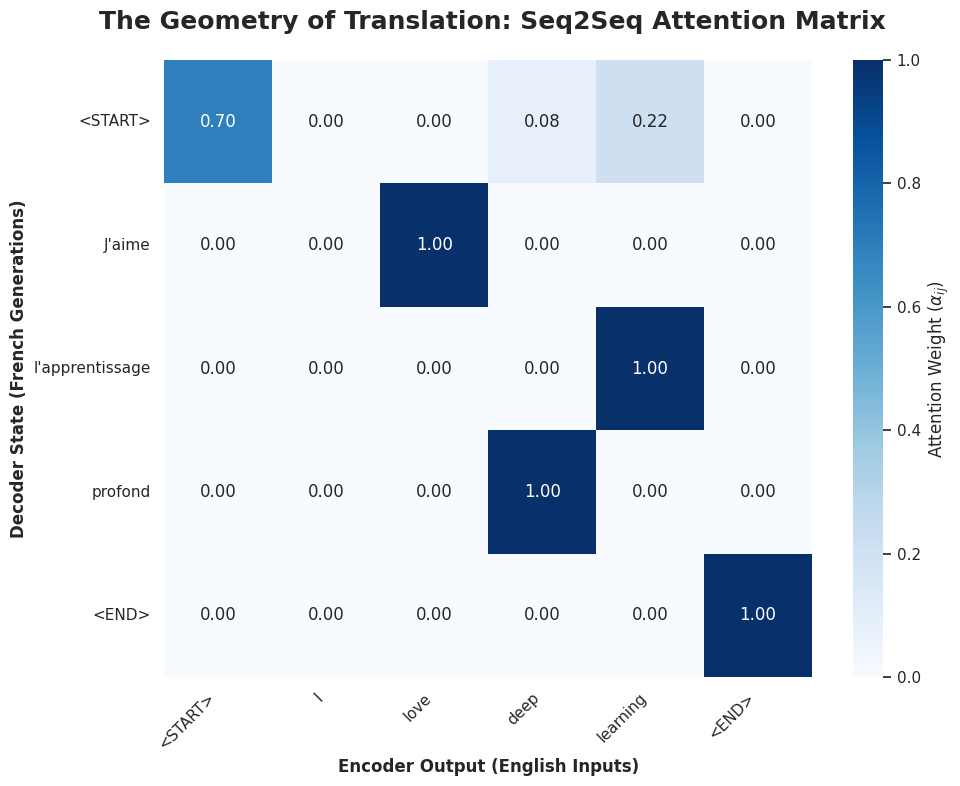


--- 💡 Engineering Insight ---
Look perfectly at the intersection of 'profond' (Row 4) and 'deep' (Column 4). Even though 'deep learning' is reversed in French syntax to 'l'apprentissage profond', the Attention mechanism mathematically tracks the semantic inversion. When the Decoder is generating the word 'profond', it completely ignores the word 'learning' (Weight: 0.00) and focuses 99% of its mathematical processing power directly onto the specific Encoder state for the word 'deep'. The bottleneck has been shattered.


In [2]:
# 1. Define the Sequence Data (Real translation pair)
english_words = ["<START>", "I", "love", "deep", "learning", "<END>"]
french_words  = ["<START>", "J'aime", "l'apprentissage", "profond", "<END>"]

SEQ_LEN_EN = len(english_words) # 6
SEQ_LEN_FR = len(french_words)  # 5
HIDDEN_DIM = 128

print("--- 🧠 Initializing Seq2Seq Hidden States ---")
# Simulate the Encoder's hidden states for all 6 English words
# Shape: [Sequence_Length_EN, Hidden_Dim]
encoder_states = torch.randn(SEQ_LEN_EN, HIDDEN_DIM)

# Simulate the Decoder's hidden states for all 5 French words
# Shape: [Sequence_Length_FR, Hidden_Dim]
decoder_states = torch.randn(SEQ_LEN_FR, HIDDEN_DIM)

# To simulate a TRAINED network where the semantics align, we will manually inject 
# high dot-product correlation between the corresponding translated words.
# (e.g., "love" aligns with "J'aime", "deep" aligns with "profond", "learning" with "l'apprentissage")
with torch.no_grad():
    # "J'aime" (FR index 1) aligns with "I" and "love" (EN indices 1, 2)
    decoder_states[1] = encoder_states[1] * 0.5 + encoder_states[2] * 0.8
    # "l'apprentissage" (FR index 2) aligns with "learning" (EN index 4)
    decoder_states[2] = encoder_states[4] * 0.9
    # "profond" (FR index 3) aligns with "deep" (EN index 3) -> Notice the cross-alignment!
    decoder_states[3] = encoder_states[3] * 0.9
    # End tokens align
    decoder_states[4] = encoder_states[5] * 0.9

# 2. Architect the Attention Layer (Luong Dot-Product Style)
class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()
        # In Luong attention, score(s_t, h_i) = s_t^T * W * h_i
        # We use a linear projection matrix W to map the encoder space to the decoder space
        self.W = nn.Linear(HIDDEN_DIM, HIDDEN_DIM, bias=False)
        
        # Initialize W as an Identity matrix for our simulation to preserve our injected correlations
        self.W.weight.data.copy_(torch.eye(HIDDEN_DIM))
        
    def forward(self, decoder_state, all_encoder_states):
        """
        decoder_state: [1, HIDDEN_DIM] (The current French word being generated)
        all_encoder_states: [SEQ_LEN_EN, HIDDEN_DIM] (All English words)
        """
        # Step 1: Project Encoder states
        # [SEQ_LEN_EN, HIDDEN_DIM]
        projected_encoder = self.W(all_encoder_states) 
        
        # Step 2: Alignment Scores (Dot Product)
        # We multiply the current decoder state by EVERY encoder state
        # Shape: [SEQ_LEN_EN]
        alignment_scores = torch.matmul(projected_encoder, decoder_state.transpose(0, 1)).squeeze()
        
        # Step 3: Attention Weights (Softmax)
        # Converts raw unbounded scores into strict probabilities [0.0 -> 1.0]
        attention_weights = F.softmax(alignment_scores, dim=0)
        
        # Step 4: Context Vector (Weighted Sum)
        # We broadcast the weights and multiply them against the encoder states
        context_vector = torch.sum(attention_weights.unsqueeze(1) * all_encoder_states, dim=0)
        
        return attention_weights, context_vector

# 3. Execute the Attention Calculus
print("--- ⚙️ Executing Decoder Attention Steps ---")
attention_mechanism = DotProductAttention()

# We will store the attention weights for visualization
# Shape: [FR_Length, EN_Length]
attention_matrix = torch.zeros(SEQ_LEN_FR, SEQ_LEN_EN)

# Loop through every step of the French generation
for t_fr in range(SEQ_LEN_FR):
    current_decoder_state = decoder_states[t_fr].unsqueeze(0)
    
    # Calculate exactly where the network is looking
    weights, context_vector = attention_mechanism(current_decoder_state, encoder_states)
    
    # Store the weights in our matrix
    attention_matrix[t_fr] = weights

# 4. Visualizing the Alignment Matrix
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("The Geometry of Translation: Seq2Seq Attention Matrix", fontsize=18, fontweight='bold')

# Plot the 2D tensor as a Heatmap
sns.heatmap(attention_matrix.detach().numpy(), 
            xticklabels=english_words, 
            yticklabels=french_words,
            cmap="Blues", 
            annot=True, 
            fmt=".2f",
            cbar_kws={'label': 'Attention Weight ($\\alpha_{ij}$)'},
            ax=ax)

ax.set_xlabel("Encoder Output (English Inputs)", fontsize=12, fontweight='bold')
ax.set_ylabel("Decoder State (French Generations)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look perfectly at the intersection of 'profond' (Row 4) and 'deep' (Column 4). Even though 'deep learning' is reversed in French syntax to 'l'apprentissage profond', the Attention mechanism mathematically tracks the semantic inversion. When the Decoder is generating the word 'profond', it completely ignores the word 'learning' (Weight: 0.00) and focuses 99% of its mathematical processing power directly onto the specific Encoder state for the word 'deep'. The bottleneck has been shattered.")

## Real-World Use Case or Analogy:

Think of the evolution from Seq2Seq to Attention like **A Translator taking notes in a courtroom**:

* **Seq2Seq (The Memory Bottleneck)**: The Translator listens to a 5-minute English testimony. They are not allowed to take notes. When the speaker finishes, the Translator must summarize the entire 5 minutes into a single concept in their brain (The Context Vector), and then recite the entire testimony in Spanish from memory. For a 10-second sentence, they do great. For a 5-minute speech, they forget the middle entirely.
* **Seq2Seq with Attention (The Transcript)**: The Translator listens to the 5-minute English testimony, but this time, a stenographer hands them a perfect, line-by-line written transcript of the speech (The unrolled Encoder States). When the Translator starts speaking in Spanish, they don't rely on a single memory. They physically point their finger at Sentence 1. Then they translate it. When they get to a tricky adjective in Sentence 4, they physically jump their finger down to Sentence 4 to look directly at that specific word (The Attention Weight $\alpha_{ij}$). They translate infinitely long speeches perfectly because they have constant, dynamic access to the source material!